In [1]:
import subprocess, sys
pkgs = [
    "tab-transformer-pytorch", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "seaborn", "ipywidgets",
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)
print("Cai dat hoan tat")

Cai dat hoan tat


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from tab_transformer_pytorch import FTTransformer

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef, roc_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("PyTorch :", torch.__version__)
print("FTTransformer imported OK")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", DEVICE)

PyTorch : 2.9.0+cu126
FTTransformer imported OK
Device  : cuda


In [3]:
CSV_PATH  = "/kaggle/input/datasets/iqsnguyn/lancuoidibennhau/Denguediseasesdataset1003.csv_clean.csv"  
LABEL_COL = "Final Output"        

N_FOLDS      = 5
EPOCHS       = 20
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-5
SEED         = 42

DIM_HIDDEN = 32  
DEPTH      = 6   
HEADS      = 8    
ATTN_DROP  = 0.1
FF_DROP    = 0.1

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config loaded | device =", DEVICE)

Config loaded | device = cuda


In [4]:
def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return dict(
        AUROC       = roc_auc_score(y_true, y_prob),
        Accuracy    = accuracy_score(y_true, y_pred),
        Sensitivity = sens,
        Specificity = spec,
        PPV         = ppv,
        NPV         = npv,
        Kappa       = cohen_kappa_score(y_true, y_pred),
        Threshold   = threshold,
        TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
    )


def tune_threshold_mcc(y_true, y_prob, n=200):
    best_mcc, best_thr = -2.0, 0.5
    for thr in np.linspace(0.01, 0.99, n):
        mcc = matthews_corrcoef(y_true, (y_prob >= thr).astype(int))
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return float(best_thr)


def build_ft_transformer(num_features):
    return FTTransformer(
        categories     = (),
        num_continuous = num_features,
        dim            = DIM_HIDDEN,
        depth          = DEPTH,
        heads          = HEADS,
        attn_dropout   = ATTN_DROP,
        ff_dropout     = FF_DROP,
        dim_out        = 1,
    ).to(DEVICE)


def make_loader(x_num, y, batch_size, shuffle):
    return DataLoader(
        TensorDataset(x_num, y),
        batch_size=batch_size,
        shuffle=shuffle,
    )


def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    # FTTransformer signature: forward(cat_tensor, num_tensor)
    # Vì không có categorical feature, truyền tensor rỗng
    empty_cat = torch.zeros(1, 0, dtype=torch.long, device=DEVICE)
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_num, y_b in loader:
            x_num = x_num.to(DEVICE)
            y_b   = y_b.to(DEVICE)
            cat_b = empty_cat.expand(x_num.size(0), -1)
            if train:
                optimizer.zero_grad()
            logits = model(cat_b, x_num).squeeze(-1)
            loss   = criterion(logits, y_b)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y_b.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().tolist()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy().tolist())
    return total_loss / len(all_labels), np.array(all_probs), np.array(all_labels)


print("Ham tien ich san sang")

Ham tien ich san sang


In [5]:
df = pd.read_csv(CSV_PATH)
assert LABEL_COL in df.columns, "Khong tim thay cot nhan: " + LABEL_COL

raw_label   = df[LABEL_COL]
unique_vals = sorted(raw_label.dropna().astype(str).unique())
print("Gia tri nhan trong CSV:", unique_vals)

try:
    df[LABEL_COL] = raw_label.astype(float).astype(int)
    print("Nhan kieu so — su dung truc tiep.")
except (ValueError, TypeError):
    label_map = {v: i for i, v in enumerate(unique_vals)}
    print("Nhan kieu text. Auto-map:", label_map)
    print(">>> Neu map sai, sua dong label_map trong cell nay roi chay lai.")
    print("    Vi du: label_map = {\"negative\": 0, \"positive\": 1}")
    df[LABEL_COL] = raw_label.map(label_map).astype(int)

assert df[LABEL_COL].isin([0, 1]).all(), "Nhan chua duoc map ve 0/1!"

n_pos = int(df[LABEL_COL].sum())
n_neg = len(df) - n_pos

info_html = (
    "<div style='background:#1e1e2e;color:#cdd6f4;padding:16px 24px;"
    "border-radius:10px;font-family:monospace;line-height:2.2'>"
    "<b style='color:#89b4fa;font-size:1.1em'>Thong tin du lieu</b><br>"
    "Tong mau   : <b style='color:#a6e3a1'>" + str(len(df)) + "</b><br>"
    "So cot     : <b style='color:#a6e3a1'>" + str(df.shape[1]) + "</b><br>"
    "Duong tinh : <b style='color:#f38ba8'>" + str(n_pos) + "</b>"
    " | Am tinh : <b style='color:#89dceb'>" + str(n_neg) + "</b>"
    " | Ti le Am/Duong : <b style='color:#fab387'>" + str(round(n_neg/max(n_pos,1),2)) + ":1</b>"
    "</div>"
)
display(HTML(info_html))
print("df shape:", df.shape)
df.head()

Gia tri nhan trong CSV: ['0.0', '1.0']
Nhan kieu so — su dung truc tiep.


df shape: (931, 9)


,Age,Sex,Haemoglobin,WBC Count,Differential Count,RBC PANEL,Platelet Count,PDW,Final Output
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


In [8]:
num_candidates = ['Haemoglobin', 'Age', 'WBC Count', 'Differential Count', 'Platelet Count', 'PDW', 'Sex' ]
print("So features kha dung:", len(num_candidates))
print("Features:", num_candidates)

w_feat = widgets.SelectMultiple(
    options     = num_candidates,
    value       = num_candidates,
    description = "Features:",
    style       = {"description_width": "initial"},
    layout      = widgets.Layout(width="65%", height="250px"),
)

btn_confirm = widgets.Button(
    description  = "Xac nhan chon",
    button_style = "success",
    layout       = widgets.Layout(width="160px", height="38px"),
)
out_confirm = widgets.Output()

SELECTED_FEATURES = list(num_candidates)

def on_confirm(b):
    global SELECTED_FEATURES
    SELECTED_FEATURES = list(w_feat.value)
    with out_confirm:
        clear_output()
        msg = (
            "<div style='background:#1e1e2e;color:#a6e3a1;padding:10px 18px;"
            "border-radius:8px;font-family:monospace'>"
            "Da chon <b>" + str(len(SELECTED_FEATURES)) + "</b> features:<br>"
            "<span style='color:#89b4fa'>" + ", ".join(SELECTED_FEATURES) + "</span></div>"
        )
        display(HTML(msg))

btn_confirm.on_click(on_confirm)

display(widgets.HTML("<b>Ctrl+Click de chon nhieu features, sau do nhan Xac nhan:</b>"))
display(widgets.HBox([w_feat, widgets.VBox([btn_confirm, out_confirm])]))

So features kha dung: 7
Features: ['Haemoglobin', 'Age', 'WBC Count', 'Differential Count', 'Platelet Count', 'PDW', 'Sex']


HTML(value='<b>Ctrl+Click de chon nhieu features, sau do nhan Xac nhan:</b>')

In [10]:
assert len(SELECTED_FEATURES) > 0, "Chua chon feature nao!"
print("So features :", len(SELECTED_FEATURES))
print("Features    :", SELECTED_FEATURES)
print()

skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_raw = df[SELECTED_FEATURES].values.astype("float32")
y_all = df[LABEL_COL].values

fold_records    = []
fold_thresholds = []
roc_data        = []

header = (
    "{:>4} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6}"
    .format("Fold","AUROC","Acc","Sens","Spec","PPV","NPV","Kappa","Thr")
)
sep = "-" * len(header)
print(sep)
print(header)
print(sep)

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_raw, y_all), 1):

    X_tr_raw  = X_raw[tr_idx]
    X_val_raw = X_raw[val_idx]
    y_tr_np   = y_all[tr_idx]
    y_val_np  = y_all[val_idx]

    # StandardScaler — fit trên train, transform trên val
    scaler    = StandardScaler()
    X_tr_sc   = scaler.fit_transform(X_tr_raw)
    X_val_sc  = scaler.transform(X_val_raw)

    x_tr  = torch.tensor(X_tr_sc,  dtype=torch.float32)
    x_val = torch.tensor(X_val_sc, dtype=torch.float32)
    y_tr  = torch.tensor(y_tr_np,  dtype=torch.float32)
    y_val = torch.tensor(y_val_np, dtype=torch.float32)

    # Class-weighted BCE loss
    n_pos_fold = int(y_tr.sum().item())
    n_neg_fold = len(y_tr) - n_pos_fold
    pos_w      = torch.tensor([n_neg_fold / max(n_pos_fold, 1)],
                               dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    tr_loader  = make_loader(x_tr,  y_tr,  BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_val, y_val, BATCH_SIZE, shuffle=False)

    model     = build_ft_transformer(len(SELECTED_FEATURES))
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_auroc  = 0.0
    best_probs  = None
    best_labels = None
    history     = {"tr_loss": [], "val_loss": [], "auroc": []}

    pbar = tqdm(range(1, EPOCHS + 1),
                desc="  Fold {}/{}".format(fold_idx, N_FOLDS),
                leave=True, ncols=95)
    for ep in pbar:
        tl, _,      _      = run_epoch(model, tr_loader,  optimizer, criterion, True)
        vl, vprobs, vlabs  = run_epoch(model, val_loader, optimizer, criterion, False)
        scheduler.step()
        try:
            auc = roc_auc_score(vlabs, vprobs)
        except Exception:
            auc = 0.5
        history["tr_loss"].append(tl)
        history["val_loss"].append(vl)
        history["auroc"].append(auc)
        pbar.set_postfix(tr="{:.4f}".format(tl),
                         val="{:.4f}".format(vl),
                         AUROC="{:.4f}".format(auc))
        if auc > best_auroc:
            best_auroc  = auc
            best_probs  = vprobs.copy()
            best_labels = vlabs.copy()

    # MCC threshold tuning
    best_thr = tune_threshold_mcc(best_labels, best_probs)
    fold_thresholds.append(best_thr)
    m = compute_metrics(best_labels, best_probs, best_thr)
    m["Fold"]    = fold_idx
    m["history"] = history
    fold_records.append(m)

    fpr, tpr, _ = roc_curve(best_labels, best_probs)
    roc_data.append((fpr, tpr, best_auroc, fold_idx))

    print("{:>4} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f}"
          .format(fold_idx, m["AUROC"], m["Accuracy"], m["Sensitivity"],
                  m["Specificity"], m["PPV"], m["NPV"], m["Kappa"], best_thr))

MEAN_THR = float(np.mean(fold_thresholds))
print(sep)
print("Hoan thanh! Mean MCC-threshold =", round(MEAN_THR, 4))

So features : 6
Features    : ['Haemoglobin', 'Age', 'WBC Count', 'Differential Count', 'Platelet Count', 'PDW']

----------------------------------------------------------------------------
Fold |  AUROC |    Acc |   Sens |   Spec |    PPV |    NPV |  Kappa |    Thr
----------------------------------------------------------------------------


  Fold 1/5:   0%|                                                       | 0/20 [00:00<?, ?it/s]

   1 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 0.3055


  Fold 2/5:   0%|                                                       | 0/20 [00:00<?, ?it/s]

   2 | 1.0000 | 0.9946 | 1.0000 | 0.9833 | 0.9921 | 1.0000 | 0.9876 | 0.1282


...

   3 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 0.6896


  Fold 4/5:   0%|                                                       | 0/20 [00:00<?, ?it/s]

   4 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 0.6551


  Fold 5/5:   0%|                                                       | 0/20 [00:00<?, ?it/s]

   5 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 0.4138
----------------------------------------------------------------------------
Hoan thanh! Mean MCC-threshold = 0.4384


In [11]:
METRIC_KEYS = ["AUROC", "Accuracy", "Sensitivity", "Specificity",
               "PPV", "NPV", "Kappa", "Threshold"]

fold_df = pd.DataFrame([
    {k: r[k] for k in ["Fold"] + METRIC_KEYS + ["TP","TN","FP","FN"]}
    for r in fold_records
])
fold_df.to_csv("fold_metrics.csv", index=False, float_format="%.6f")

summary_rows = []
for k in METRIC_KEYS:
    vals = fold_df[k].values
    summary_rows.append(dict(
        Metric = k,
        Mean   = float(np.mean(vals)),
        Std    = float(np.std(vals, ddof=1)),
        Min    = float(np.min(vals)),
        Max    = float(np.max(vals)),
    ))
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("fold_metrics_summary.csv", index=False, float_format="%.6f")

print("fold_metrics.csv          da luu")
print("fold_metrics_summary.csv  da luu")
print()

display(fold_df.style
    .background_gradient(cmap="YlOrRd", subset=METRIC_KEYS)
    .format({k: "{:.4f}" for k in METRIC_KEYS})
    .set_caption("Ket qua tung Fold")
)

fold_metrics.csv          da luu
fold_metrics_summary.csv  da luu



,Fold,AUROC,Accuracy,Sensitivity,Specificity,PPV,NPV,Kappa,Threshold,TP,TN,FP,FN
0,1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.3055,127,60,0,0
1,2,1.0000,0.9946,1.0000,0.9833,0.9921,1.0000,0.9876,0.1282,126,59,1,0
2,3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.6896,126,60,0,0
3,4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.6551,126,60,0,0
4,5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4138,126,60,0,0


In [12]:
display(summary_df.style
    .background_gradient(cmap="Blues", subset=["Mean"])
    .format({"Mean":"{:.4f}", "Std":"{:.4f}", "Min":"{:.4f}", "Max":"{:.4f}"})
    .set_caption("Summary Mean +/- Std (5-Fold CV)")
)

,Metric,Mean,Std,Min,Max
0,AUROC,1.0000,0.0000,1.0000,1.0000
1,Accuracy,0.9989,0.0024,0.9946,1.0000
2,Sensitivity,1.0000,0.0000,1.0000,1.0000
3,Specificity,0.9967,0.0075,0.9833,1.0000
4,PPV,0.9984,0.0035,0.9921,1.0000
5,NPV,1.0000,0.0000,1.0000,1.0000
6,Kappa,0.9975,0.0055,0.9876,1.0000
7,Threshold,0.4384,0.2369,0.1282,0.6896


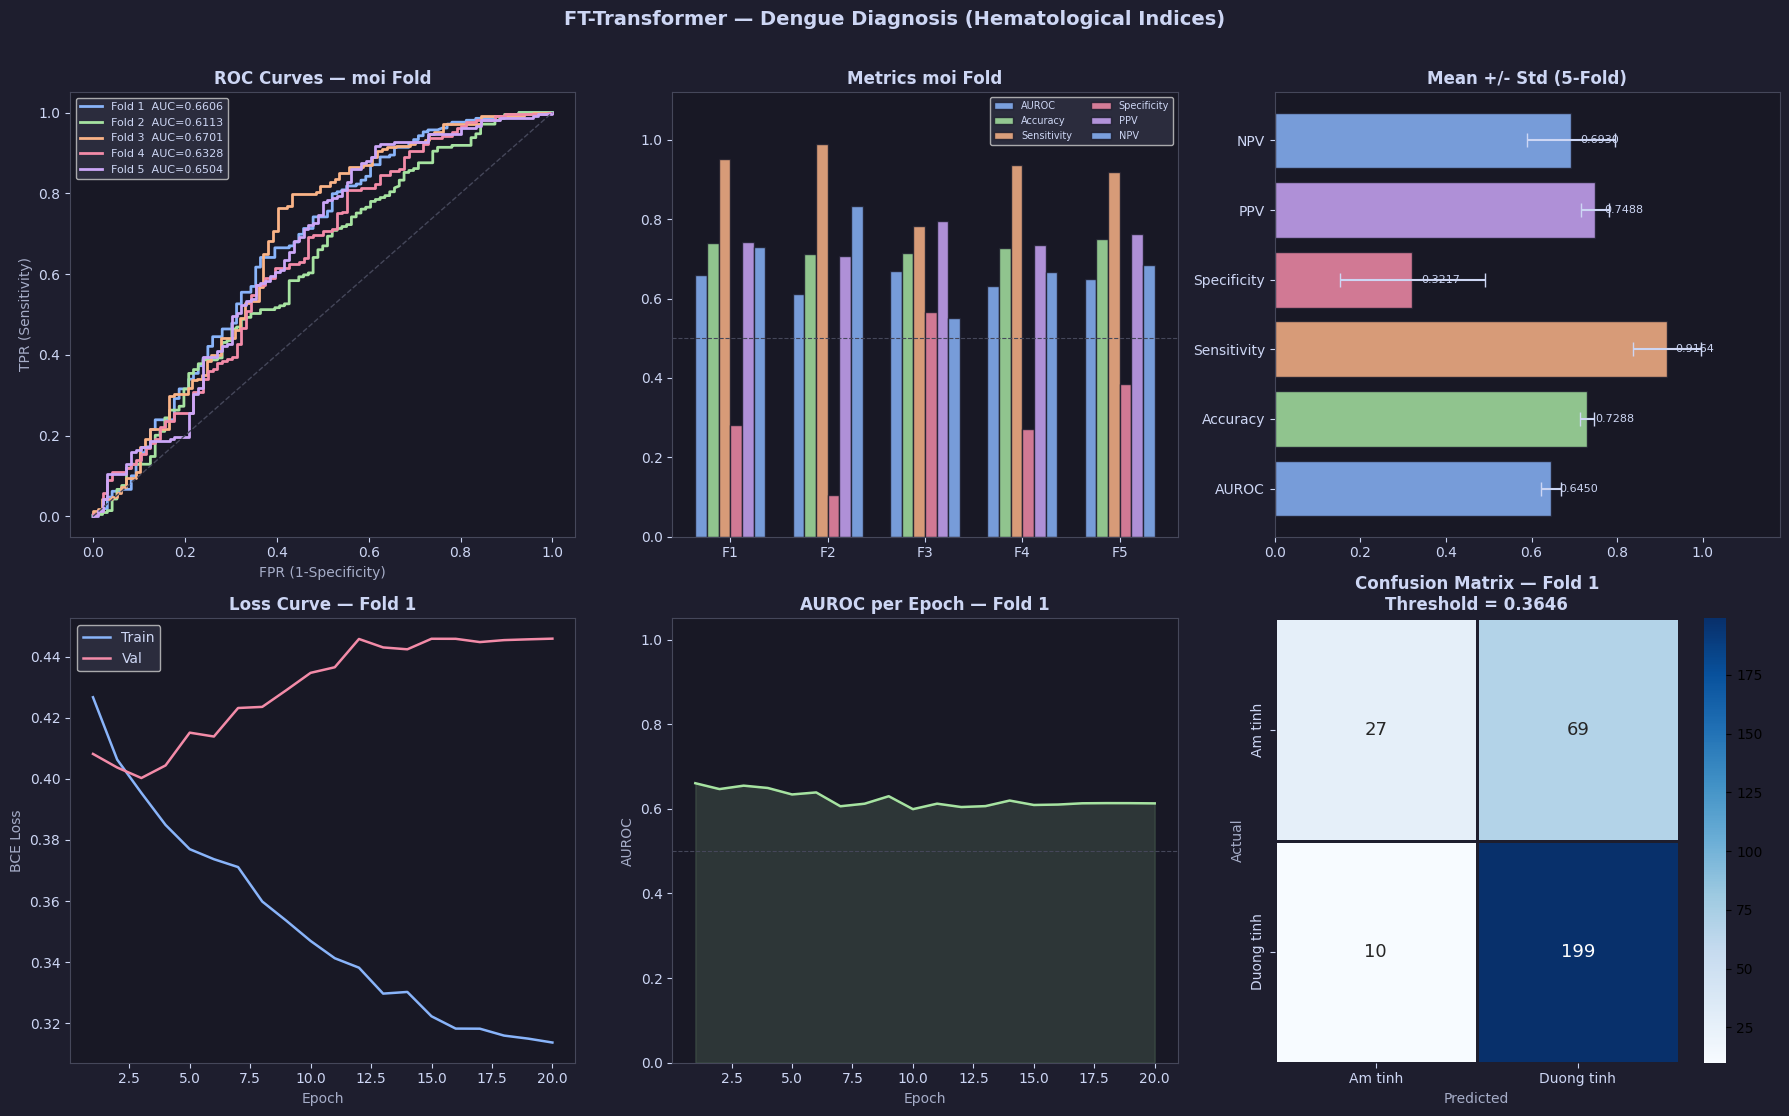

results_overview.png da luu


In [19]:
DARK    = "#1e1e2e"
PANEL   = "#181825"
BORDER  = "#45475a"
TEXT    = "#cdd6f4"
MUTED   = "#a6adc8"
PAL     = ["#89b4fa", "#a6e3a1", "#fab387", "#f38ba8", "#cba6f7"]
BM      = ["AUROC", "Accuracy", "Sensitivity", "Specificity", "PPV", "NPV"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(DARK)
for ax in axes.flat:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)

# 1. ROC curves
ax = axes[0, 0]
ax.set_title("ROC Curves — moi Fold", color=TEXT, fontweight="bold")
for fpr, tpr, auc, fi in roc_data:
    ax.plot(fpr, tpr, color=PAL[fi-1], lw=2,
            label="Fold {}  AUC={:.4f}".format(fi, auc))
ax.plot([0,1], [0,1], "--", color=BORDER, lw=1)
ax.set_xlabel("FPR (1-Specificity)", color=MUTED)
ax.set_ylabel("TPR (Sensitivity)",   color=MUTED)
ax.legend(fontsize=8, labelcolor=TEXT, facecolor="#313244")

# 2. Bar metrics per fold
ax = axes[0, 1]
ax.set_title("Metrics moi Fold", color=TEXT, fontweight="bold")
x = np.arange(N_FOLDS)
w = 0.12
for i, metric in enumerate(BM):
    vals = [fold_records[f][metric] for f in range(N_FOLDS)]
    ax.bar(x + i*w, vals, width=w, label=metric,
           color=PAL[i % len(PAL)], alpha=0.85, edgecolor=DARK)
ax.set_xticks(x + w * 2.5)
ax.set_xticklabels(["F{}".format(i+1) for i in range(N_FOLDS)], color=TEXT)
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color=BORDER, lw=0.8, ls="--")
ax.legend(fontsize=7, labelcolor=TEXT, facecolor="#313244", ncol=2)

# 3. Mean ± Std horizontal bar
ax = axes[0, 2]
ax.set_title("Mean +/- Std (5-Fold)", color=TEXT, fontweight="bold")
means = [summary_df.loc[summary_df.Metric==m, "Mean"].values[0] for m in BM]
stds  = [summary_df.loc[summary_df.Metric==m, "Std"].values[0]  for m in BM]
bars  = ax.barh(BM, means, xerr=stds, color=PAL[:len(BM)],
                align="center", alpha=0.85,
                capsize=5, ecolor=TEXT, edgecolor=DARK)
ax.set_xlim(0, 1.18)
ax.tick_params(axis="y", labelcolor=TEXT)
for bar, val in zip(bars, means):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            "{:.4f}".format(val), va="center", color=TEXT, fontsize=8)

# 4. Loss curve Fold 1
ax  = axes[1, 0]
h   = fold_records[0]["history"]
eps = range(1, len(h["tr_loss"]) + 1)
ax.set_title("Loss Curve — Fold 1", color=TEXT, fontweight="bold")
ax.plot(eps, h["tr_loss"],  color="#89b4fa", lw=1.8, label="Train")
ax.plot(eps, h["val_loss"], color="#f38ba8", lw=1.8, label="Val")
ax.set_xlabel("Epoch", color=MUTED)
ax.set_ylabel("BCE Loss", color=MUTED)
ax.legend(labelcolor=TEXT, facecolor="#313244")

# 5. AUROC per epoch Fold 1
ax = axes[1, 1]
ax.set_title("AUROC per Epoch — Fold 1", color=TEXT, fontweight="bold")
ax.plot(eps, h["auroc"], color="#a6e3a1", lw=1.8)
ax.fill_between(eps, h["auroc"], alpha=0.15, color="#a6e3a1")
ax.axhline(0.5, color=BORDER, lw=0.8, ls="--")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch", color=MUTED)
ax.set_ylabel("AUROC",  color=MUTED)

# 6. Confusion matrix Fold 1
ax = axes[1, 2]
r0 = fold_records[0]
ax.set_title(
    "Confusion Matrix — Fold 1\nThreshold = {:.4f}".format(r0["Threshold"]),
    color=TEXT, fontweight="bold"
)
cm_arr = np.array([[r0["TN"], r0["FP"]], [r0["FN"], r0["TP"]]])
sns.heatmap(cm_arr, annot=True, fmt="d", ax=ax, cmap="Blues",
            xticklabels=["Am tinh", "Duong tinh"],
            yticklabels=["Am tinh", "Duong tinh"],
            linewidths=1, linecolor=DARK, annot_kws={"size": 13})
ax.set_xlabel("Predicted", color=MUTED)
ax.set_ylabel("Actual",    color=MUTED)
ax.tick_params(colors=TEXT)

plt.suptitle(
    "FT-Transformer — Dengue Diagnosis (Hematological Indices)",
    fontsize=14, color=TEXT, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("results_overview.png", dpi=150,
            bbox_inches="tight", facecolor=DARK)
plt.show()
print("results_overview.png da luu")

In [ ]:
color_map = {
    "AUROC": "#a6e3a1", "Accuracy": "#89b4fa",
    "Sensitivity": "#f38ba8", "Specificity": "#89dceb",
    "PPV": "#fab387",   "NPV": "#cba6f7",
    "Kappa": "#f9e2af", "Threshold": "#585b70",
}

rows_html = ""
for _, row in summary_df.iterrows():
    c = color_map.get(row["Metric"], "#cdd6f4")
    rows_html += (
        "<tr>"
        "<td style='color:" + c + ";font-weight:bold;padding:4px 16px'>" + str(row["Metric"]) + "</td>"
        "<td style='color:#cdd6f4;padding:4px 16px'>" + "{:.4f}".format(row["Mean"]) + "</td>"
        "<td style='color:#a6adc8;padding:4px 16px'>+/- " + "{:.4f}".format(row["Std"]) + "</td>"
        "<td style='color:#6c7086;padding:4px 16px'>[" + "{:.4f}".format(row["Min"]) + " - " + "{:.4f}".format(row["Max"]) + "]</td>"
        "</tr>"
    )

html_card = (
    "<div style='background:#1e1e2e;padding:20px 28px;border-radius:12px;"
    "font-family:monospace;display:inline-block'>"
    "<b style='color:#89b4fa;font-size:1.2em'>FT-Transformer 5-Fold CV Results</b>"
    "<p style='color:#a6adc8;margin:6px 0 12px'>"
    "Features: <b style='color:#89b4fa'>" + str(len(SELECTED_FEATURES)) + "</b>"
    " | Epochs: <b style='color:#89b4fa'>" + str(EPOCHS) + "</b>"
    " | dim=" + str(DIM_HIDDEN) + ", depth=" + str(DEPTH) + ", heads=" + str(HEADS) + "</p>"
    "<table style='border-collapse:collapse'>"
    "<tr style='border-bottom:1px solid #45475a'>"
    "<th style='color:#585b70;padding:4px 16px;text-align:left'>Metric</th>"
    "<th style='color:#585b70;padding:4px 16px'>Mean</th>"
    "<th style='color:#585b70;padding:4px 16px'>Std</th>"
    "<th style='color:#585b70;padding:4px 16px'>Range</th>"
    "</tr>"
    + rows_html +
    "<tr style='border-top:1px solid #45475a'>"
    "<td colspan='4' style='color:#fab387;padding:8px 16px'>"
    "Mean MCC-Threshold = <b>" + "{:.4f}".format(MEAN_THR) + "</b>"
    " (dung cho inference moi)"
    "</td></tr>"
    "</table></div>"
)
display(HTML(html_card))